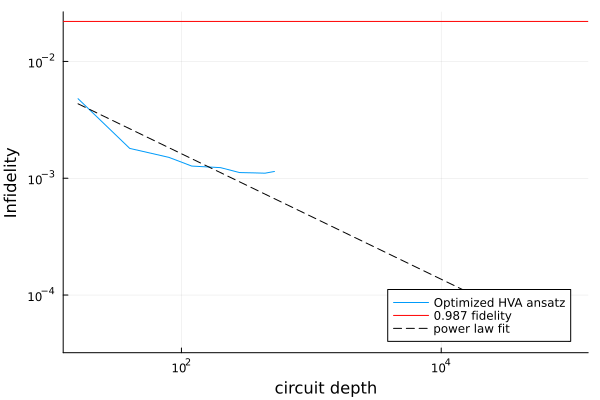

fidelity 0.022 at: 0.7794388386727993 depth


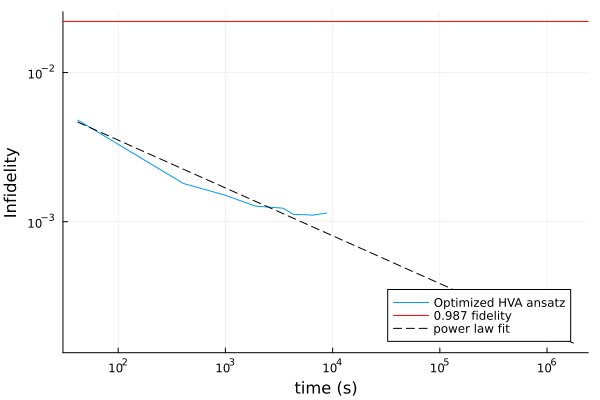

fidelity 0.022 at: 3.812503776019403e-6 days


┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


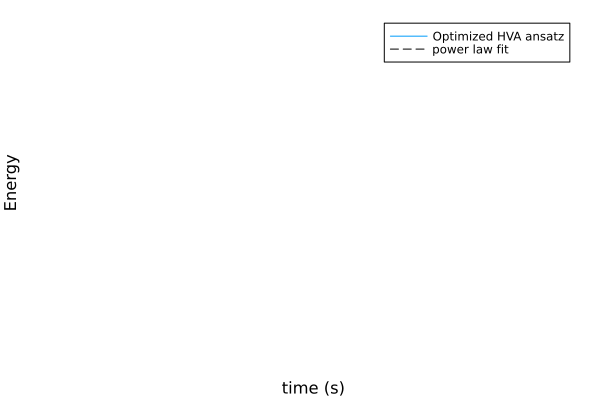

┌ Warning: Invalid negative or zero value -0.8136713163946183 found at series index 1 for log10 based yscale
└ @ Plots ~/.julia/packages/Plots/GIume/src/utils.jl:105
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: Invalid negative or zero value -0.8136713163946183 found at series index 1 for log10 based yscale
└ @ Plots ~/.julia/packages/Plots/GIume/src/utils.jl:105
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: Invalid negative or zero value -0.8136713163946183 found at series index 1 for log10 based yscale
└ @ Plots ~/.julia/packages/Plots/GIume/src/utils.jl:105


0.022

In [2]:
using CSV, DataFrames
using Plots
using LsqFit

func(x,p) = p[1].*x.^(p[2])
func2(x,p) = p[1].*x.^(p[2]).+p[3]

path = "/home/jek354/research/ML-signproblem/experimenting/ed/benchmarks/hva_parameter_sweep_N_3_3_3x3_u8_eigref"
df = nothing
for file in readdir(path)
    # if endswith(file, "_gpu.csv")
        df_tmp = CSV.read(joinpath(path, file), DataFrame)
        if df === nothing
            df = df_tmp
        else
            append!(df, df_tmp)
        end
    # end
end
sort!(df, :n_params)

fit = curve_fit(func, df.n_layers*8, df.infidelity, [1.0, -1.0])
p = plot(df.n_layers*8, df.infidelity, label="Optimized HVA ansatz", ylabel="Infidelity", xlabel="circuit depth", yscale=:log10, xscale=:log10)
hline!(p, [0.022], label="0.987 fidelity", c="red")
x = LinRange(minimum(df.n_layers*8), maximum(df.n_layers*8)*200,200)
plot!(p, x, func(x, fit.param), label="power law fit", c="black", linestyle=:dash)
display(p)
target_fidelity = 0.022
println("fidelity $target_fidelity at: $((target_fidelity/fit.param[1])^(1/fit.param[2])) depth")


fit = curve_fit(func, df.elapsed_s, df.infidelity, [1.0, -1.0])
p = plot(df.elapsed_s, df.infidelity, label="Optimized HVA ansatz", ylabel="Infidelity", xlabel="time (s)", yscale=:log10, xscale=:log10)
hline!(p, [0.022], label="0.987 fidelity", c="red")
x = LinRange(minimum(df.elapsed_s), maximum(df.elapsed_s)*200,200)
plot!(p, x, func(x, fit.param), label="power law fit", c="black", linestyle=:dash)
display(p)
target_fidelity = 0.022
println("fidelity $target_fidelity at: $((target_fidelity/fit.param[1])^(1/fit.param[2])/60/60/24) days")


# gs = -10.166303601979678
# fit = curve_fit(func, df.elapsed_s, df.energy.-gs, [1.0, -1.0])
# p = plot(df.elapsed_s, df.energy.-gs, label="Optimized HVA ansatz", ylabel="Energy", xlabel="time (s)", yscale=:log10, xscale=:log10)
# # hline!(p, [0.022], label="0.987 fidelity", c="red")
# x = LinRange(minimum(df.elapsed_s), maximum(df.elapsed_s),200)
# plot!(p, x, func(x, fit.param), label="power law fit", c="black", linestyle=:dash)
# display(p)
# target_fidelity = 0.022
# println("fidelity $target_fidelity at: $((target_fidelity/fit.param[1])^(1/fit.param[2])/60/60/24) days")


In [3]:
fit.param

2-element Vector{Float64}:
  4.043174596695857
 -0.45206580223836673